## Proyecto data science- Python

Inicialmente para que nos permita interactuar con la configuración interna de Python se importa SYS,con el objetivo de que se logre trabajar con rutas de forma segura 

In [1]:
import sys
from pathlib import Path

#Path().resolve() obtiene la ruta ABSOLUTA del directorio actual
#parent sube UN nivel en la estructura de carpetas:
root_path = Path().resolve().parent
sys.path.append(str(root_path))

# Imprimimos la ruta raíz solo para verificar que es correcta
print(root_path)


D:\camil\Personal\MasterDos\data_science\proyecto_dataset


### Carga del dataset turismo_europa.csv



In [2]:
from src.io import load_data
df = load_data("../data/raw/turismo_europa.csv")
df.head()

,DATAFLOW,LAST UPDATE,freq,c_resid,unit,nace_r2,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:TOUR_OCC_NINAT(1.0),30/01/26 23:00:00,Annual,Foreign country,Number,Hotels and similar accommodation,European Union - 27 countries (from 2020),2012,731662295,NaN,NaN
1,ESTAT:TOUR_OCC_NINAT(1.0),30/01/26 23:00:00,Annual,Foreign country,Number,Hotels and similar accommodation,European Union - 27 countries (from 2020),2013,763965046,NaN,NaN
2,ESTAT:TOUR_OCC_NINAT(1.0),30/01/26 23:00:00,Annual,Foreign country,Number,Hotels and similar accommodation,European Union - 27 countries (from 2020),2014,783989509,NaN,NaN
3,ESTAT:TOUR_OCC_NINAT(1.0),30/01/26 23:00:00,Annual,Foreign country,Number,Hotels and similar accommodation,European Union - 27 countries (from 2020),2015,812820626,NaN,NaN
4,ESTAT:TOUR_OCC_NINAT(1.0),30/01/26 23:00:00,Annual,Foreign country,Number,Hotels and similar accommodation,European Union - 27 countries (from 2020),2016,852319793,NaN,NaN


### Inspección mínima
En este caso no se ha realizado limpieza de los datos, lo unico que se hara es observar si se encuentrtan columnas con más missing (valores faltantes),tipos incorrectos y columnas raras

In [3]:
df.shape
df.info()
df.isna().sum().sort_values(ascending=False)


<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATAFLOW     260 non-null    str    
 1   LAST UPDATE  260 non-null    str    
 2   freq         260 non-null    str    
 3   c_resid      260 non-null    str    
 4   unit         260 non-null    str    
 5   nace_r2      260 non-null    str    
 6   geo          260 non-null    str    
 7   TIME_PERIOD  260 non-null    int64  
 8   OBS_VALUE    260 non-null    int64  
 9   OBS_FLAG     33 non-null     str    
 10  CONF_STATUS  0 non-null      float64
dtypes: float64(1), int64(2), str(8)
memory usage: 22.5 KB


CONF_STATUS    260
OBS_FLAG       227
DATAFLOW         0
freq             0
LAST UPDATE      0
c_resid          0
unit             0
geo              0
nace_r2          0
OBS_VALUE        0
TIME_PERIOD      0
dtype: int64

### Limpieza básica

Dejar el dataset usable, vamos a eliminar columnas irrelevantes, eliminar nulos, tipos correctos, normalizar categorias y eliminar duplicados

In [4]:
from src.cleaning import basic_cleaning

# 3️⃣ Aplicar limpieza al dataframe cargado
df_clean = basic_cleaning(df)

# 4️⃣ Revisar resultado
df_clean.info()
df_clean.head()


<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   freq         260 non-null    str    
 1   c_resid      260 non-null    str    
 2   unit         260 non-null    str    
 3   nace_r2      260 non-null    str    
 4   geo          260 non-null    str    
 5   TIME_PERIOD  260 non-null    int64  
 6   OBS_VALUE    260 non-null    float64
dtypes: float64(1), int64(1), str(5)
memory usage: 14.3 KB


,freq,c_resid,unit,nace_r2,geo,TIME_PERIOD,OBS_VALUE
0,Annual,foreign country,Number,Hotels and similar accommodation,EUROPEAN UNION - 27 COUNTRIES (FROM 2020),2012,731662295.0
1,Annual,foreign country,Number,Hotels and similar accommodation,EUROPEAN UNION - 27 COUNTRIES (FROM 2020),2013,763965046.0
2,Annual,foreign country,Number,Hotels and similar accommodation,EUROPEAN UNION - 27 COUNTRIES (FROM 2020),2014,783989509.0
3,Annual,foreign country,Number,Hotels and similar accommodation,EUROPEAN UNION - 27 COUNTRIES (FROM 2020),2015,812820626.0
4,Annual,foreign country,Number,Hotels and similar accommodation,EUROPEAN UNION - 27 COUNTRIES (FROM 2020),2016,852319793.0


### Pipeline 

Se implementa un pipeline end-to-end sencillo para procesar el dataset. Primero se carga el archivo crudo usando load_data(), luego se aplica la función de limpieza clean_dataset() para dejar los datos listos para análisis, y finalmente se guarda el dataset limpio en data/processed/. De esta forma, todo el proceso puede ejecutarse con un solo comando, garantizando reproducibilidad y consistencia.

In [ ]:
#Importar funciones desde src
from src.io import load_data
from src.cleaning import basic_cleaning

#Definir un "main" dentro del notebook
def main():
    # Cargar dataset crudo
    df = load_data("data/raw/turismo_europa.csv")
    print("Dataset crudo cargado:")
    display(df.head())
    
    # Limpiar dataset
    df_clean = basic_cleaning(df)
    print("\nDataset limpio:")
    display(df_clean.head())
    
    # Guardar dataset procesado
    df_clean.to_csv("data/processed/turismo_europa_clean.csv", index=False)
    print("\nPipeline completo. Dataset limpio guardado en data/processed/")
    
    return df_clean

#Ejecutar pipeline
df_clean = main()

## Features
- Feature 1: Década
- Feature 2: Log del turismo (reduce skew)
- Feature 3: Turismo internacional (binaria)

In [7]:
from src.features import build_features

# Mostrar los features
df_features = build_features(df)

# Revisar resultado
df_features.info()
df_features.head()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DATAFLOW          260 non-null    str    
 1   LAST UPDATE       260 non-null    str    
 2   freq              260 non-null    str    
 3   c_resid           260 non-null    str    
 4   unit              260 non-null    str    
 5   nace_r2           260 non-null    str    
 6   geo               260 non-null    str    
 7   TIME_PERIOD       260 non-null    int64  
 8   OBS_VALUE         260 non-null    int64  
 9   OBS_FLAG          33 non-null     str    
 10  CONF_STATUS       0 non-null      float64
 11  decade            260 non-null    int64  
 12  log_obs_value     260 non-null    float64
 13  is_international  260 non-null    int64  
dtypes: float64(2), int64(4), str(8)
memory usage: 28.6 KB


,DATAFLOW,LAST UPDATE,freq,c_resid,unit,nace_r2,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS,decade,log_obs_value,is_international
0,ESTAT:TOUR_OCC_NINAT(1.0),30/01/26 23:00:00,Annual,Foreign country,Number,Hotels and similar accommodation,European Union - 27 countries (from 2020),2012,731662295,NaN,NaN,2010,20.410830,1
1,ESTAT:TOUR_OCC_NINAT(1.0),30/01/26 23:00:00,Annual,Foreign country,Number,Hotels and similar accommodation,European Union - 27 countries (from 2020),2013,763965046,NaN,NaN,2010,20.454033,1
2,ESTAT:TOUR_OCC_NINAT(1.0),30/01/26 23:00:00,Annual,Foreign country,Number,Hotels and similar accommodation,European Union - 27 countries (from 2020),2014,783989509,NaN,NaN,2010,20.479906,1
3,ESTAT:TOUR_OCC_NINAT(1.0),30/01/26 23:00:00,Annual,Foreign country,Number,Hotels and similar accommodation,European Union - 27 countries (from 2020),2015,812820626,NaN,NaN,2010,20.516021,1
4,ESTAT:TOUR_OCC_NINAT(1.0),30/01/26 23:00:00,Annual,Foreign country,Number,Hotels and similar accommodation,European Union - 27 countries (from 2020),2016,852319793,NaN,NaN,2010,20.563472,1


### Visualizaciones

**Grafico Evolucion del turismo en Europa**

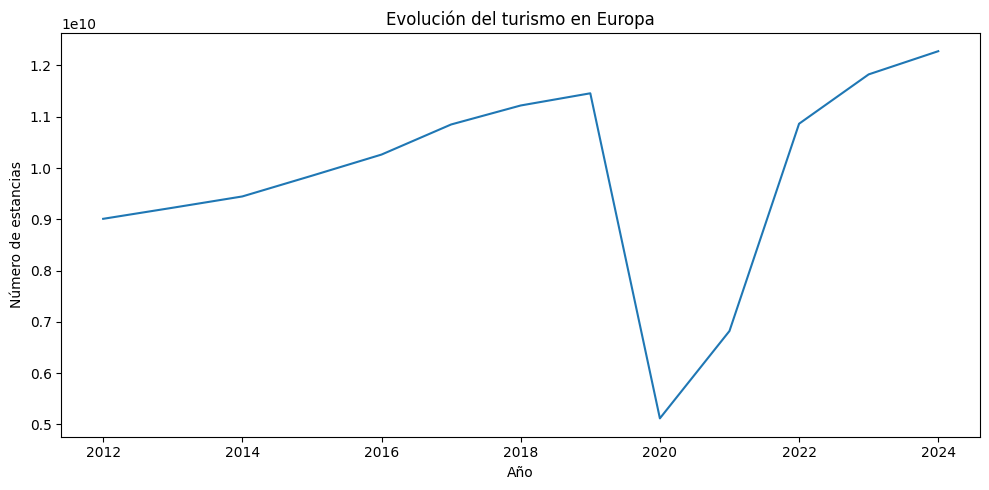

In [ ]:
from src.viz import plot_tourism_by_year

df_viz = plot_tourism_by_year(df) 

Se observa un crecmineto sostenido del turismo hasta el 2019, una caida abrupta en 2020 debido a la pandemia, y una recuperacion pregresiva posterior

**Comparacion: Top 10 paises con mayor estancias**

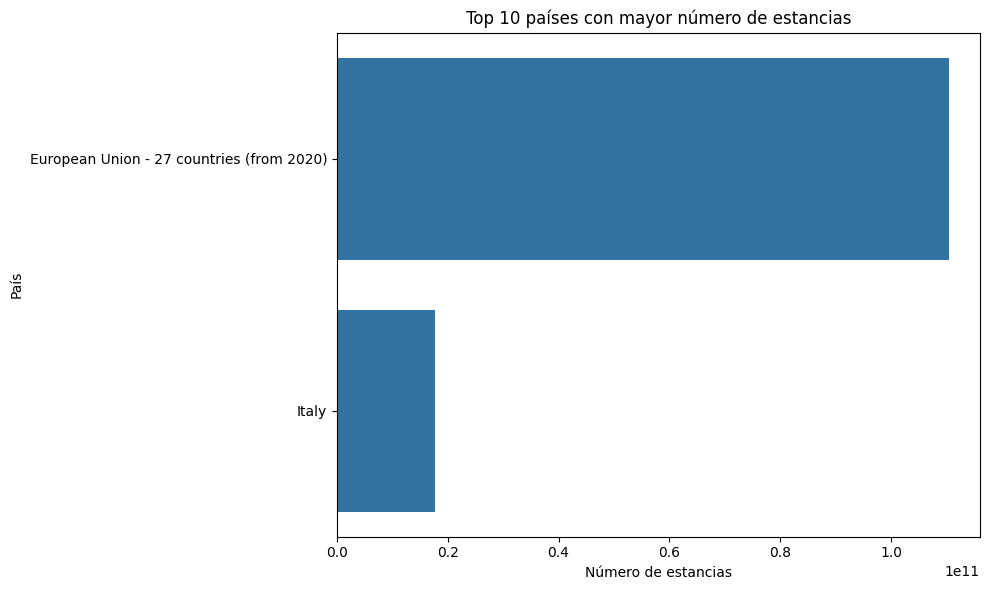

In [ ]:
from src.viz import plot_top_countries

# Top N países con mayor numero de estancias
df_viz = plot_top_countries(df)

Muestra que el total agregado de la Unión Europea concentra un volumen de estancias muy superior al de cualquier país individual, reflejando el peso global del bloque en el turismo. Entre los países, Italia destaca como uno de los principales destinos, aunque para una comparación más precisa sería conveniente excluir el agregado europeo y centrarse solo en países individuales.

**Turismo nacional vs internacional**

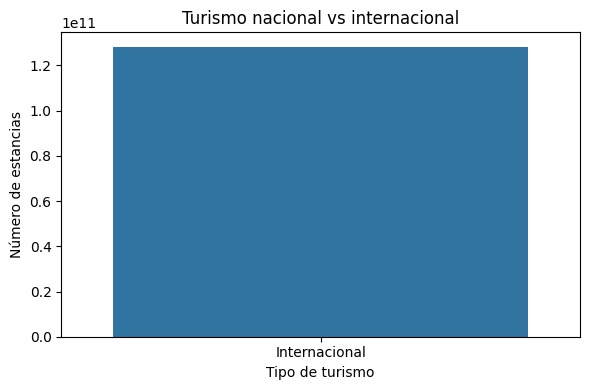

In [8]:
from src.viz import plot_domestic_vs_international

# Turismo nacional vs internacional
df_viz = plot_domestic_vs_international(df)

Muestra que el turismo internacional concentra un volumen muy elevado de estancias, lo que evidencia su fuerte peso dentro del sector turístico europeo. La diferencia observada sugiere que los flujos internacionales representan una parte fundamental de la demanda, consolidando a Europa como un destino altamente atractivo para viajeros extranjeros.

**Distribución de estancias (histograma)**

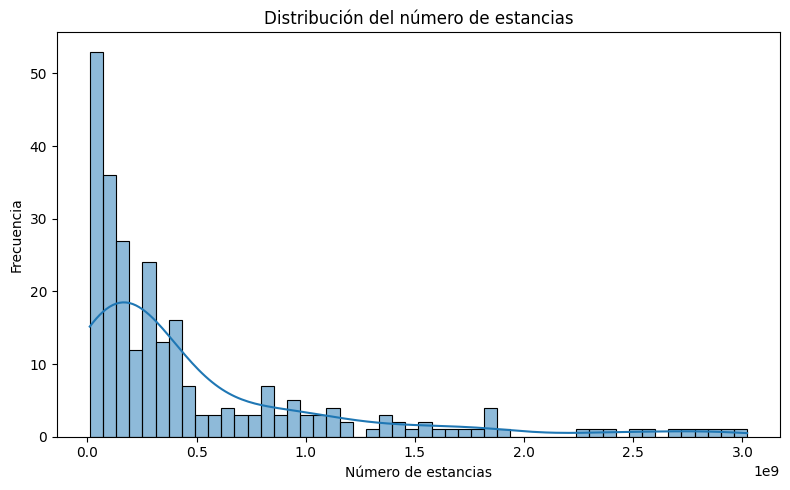

In [ ]:
from src.viz import plot_distribution_obs_value

# Turismo nacional vs internacional
df_viz = plot_distribution_obs_value(df)

Muestra que la distribución del número de estancias está fuertemente sesgada a la derecha, con una alta concentración de valores bajos y pocos casos con volúmenes muy elevados. Esto indica que la mayoría de los países o periodos registran niveles moderados de turismo, mientras que un número reducido concentra cifras significativamente superiores, generando una cola larga en la distribución.